# 🧠 Autoencoder for Image Denoising using MNIST
---

### Submitted By:
**Name:** Rishu Sharma

### Course:
Deep Learning / Data Science

### Project Objective:
To build a Deep Learning model using a Convolutional Autoencoder that can remove noise from handwritten digit images from the MNIST dataset.

---

### Technologies Used:
- Python
- TensorFlow/Keras
- NumPy
- Matplotlib
- Scikit-Learn

---

### Dataset:
MNIST Handwritten Digit Dataset

---

# 1. Introduction

Image denoising is an important task in computer vision and image processing. The objective is to reconstruct a clean image from a noisy image.

Autoencoders are unsupervised neural networks that learn compressed representations of data and reconstruct the original data from those representations.

In this project, we will:

- Load the MNIST dataset.
- Add artificial Gaussian noise.
- Build a Convolutional Autoencoder.
- Train the model.
- Remove noise from images.
- Evaluate the performance of the model.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.models import Model

from sklearn.metrics import mean_squared_error

# 2. Loading the Dataset

The MNIST dataset contains:

- 60,000 training images
- 10,000 testing images

Each image has dimensions:

28 × 28 pixels

In [5]:
(x_train,_),(x_test,_) = mnist.load_data()

print("Training Shape:",x_train.shape)
print("Testing Shape:",x_test.shape)

Training Shape: (60000, 28, 28)
Testing Shape: (10000, 28, 28)


# 3. Data Preprocessing

Before feeding images to the neural network:

- Convert image values to float.
- Normalize values between 0 and 1.
- Reshape images to include channel dimensions.

In [6]:
x_train = x_train.astype('float32')/255.
x_test = x_test.astype('float32')/255.

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


# 4. Visualizing Original Images

Below are some sample images from the MNIST dataset.

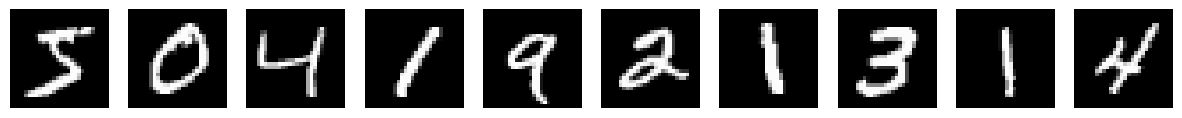

In [7]:
plt.figure(figsize=(15,3))

for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(x_train[i].reshape(28,28),
               cmap='gray')
    plt.axis('off')

plt.show()

# 5. Adding Gaussian Noise

To train the denoising autoencoder, we artificially add Gaussian noise to the original images.

Formula:

Noisy Image = Original Image + Gaussian Noise

In [8]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor*np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor*np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy,0.,1.)
x_test_noisy = np.clip(x_test_noisy,0.,1.)

# 6. Visualizing Noisy Images

The following images contain artificial Gaussian noise.

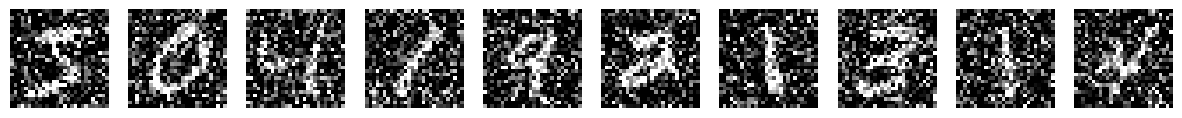

In [9]:
plt.figure(figsize=(15,3))

for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(x_train_noisy[i].reshape(28,28),
               cmap='gray')
    plt.axis('off')

plt.show()

# 7. Building the Convolutional Autoencoder

The autoencoder consists of two parts:

## Encoder
- Extracts important features
- Compresses the image

## Decoder
- Reconstructs the original image
- Removes unwanted noise

In [10]:
input_img = Input(shape=(28,28,1))

# Encoder
x = Conv2D(32,(3,3),
           activation='relu',
           padding='same')(input_img)

x = MaxPooling2D((2,2),
                 padding='same')(x)

x = Conv2D(32,(3,3),
           activation='relu',
           padding='same')(x)

encoded = MaxPooling2D((2,2),
                       padding='same')(x)

# Decoder
x = Conv2D(32,(3,3),
           activation='relu',
           padding='same')(encoded)

x = UpSampling2D((2,2))(x)

x = Conv2D(32,(3,3),
           activation='relu',
           padding='same')(x)

x = UpSampling2D((2,2))(x)

decoded = Conv2D(1,
                 (3,3),
                 activation='sigmoid',
                 padding='same')(x)

autoencoder = Model(input_img,decoded)

# 8. Compiling the Model

Optimizer Used:
- Adam

Loss Function:
- Binary Crossentropy

In [11]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

# 9. Training the Autoencoder

The model learns to reconstruct the original image from the noisy image.

In [12]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(
        x_test_noisy,
        x_test
    )
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 92ms/step - loss: 0.1650 - val_loss: 0.1171
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - loss: 0.1144 - val_loss: 0.1092
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 88ms/step - loss: 0.1085 - val_loss: 0.1053
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 91ms/step - loss: 0.1054 - val_loss: 0.1040
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 88ms/step - loss: 0.1034 - val_loss: 0.1014
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 92ms/step - loss: 0.1020 - val_loss: 0.1003
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 88s 104ms/step - loss: 0.1010 - val_loss: 0.0994
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 105ms/step - loss: 0.1002 - val_loss: 0.0989
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 78s 97ms/step - loss: 0.0995 - val_loss: 0.0983
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 100ms/step - loss: 0.0988 - val_loss: 0.0977


# 10. Training Performance

The graph below shows the training and validation loss.

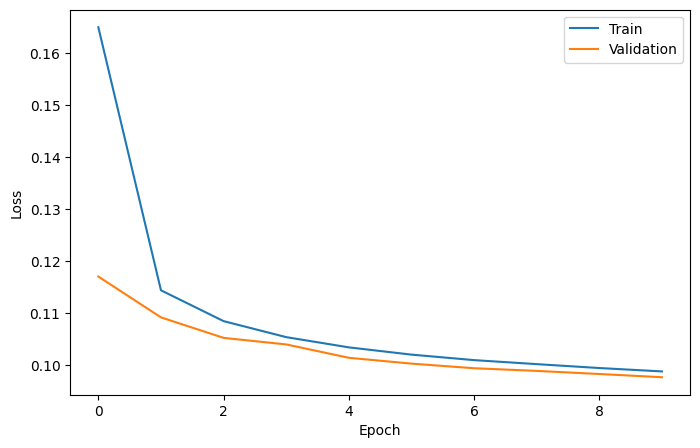

In [13]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Train','Validation'])

plt.show()

# 11. Denoising the Images

The trained autoencoder predicts the clean images from noisy images.

In [14]:
decoded_imgs = autoencoder.predict(
    x_test_noisy
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step


# 12. Results

The following figure shows:

- Row 1 : Noisy Images
- Row 2 : Denoised Images
- Row 3 : Original Images

In [ ]:
n=10

plt.figure(figsize=(20,6))

for i in range(n):

    ax=plt.subplot(3,n,i+1)
    plt.imshow(
        x_test_noisy[i].reshape(28,28),
        cmap='gray'
    )
    plt.axis('off')

    ax=plt.subplot(3,n,i+n+1)
    plt.imshow(
        decoded_imgs[i].reshape(28,28),
        cmap='gray'
    )
    plt.axis('off')

    ax=plt.subplot(3,n,i+2*n+1)
    plt.imshow(
        x_test[i].reshape(28,28),
        cmap='gray'
    )
    plt.axis('off')

plt.show()

# 13. Model Evaluation

We calculate the Mean Squared Error (MSE) between:

- Original images
- Reconstructed images

In [ ]:
mse = mean_squared_error(
    x_test.flatten(),
    decoded_imgs.flatten()
)

print("MSE:",mse)

# 14. Saving the Model

The trained autoencoder is saved for future use.

In [ ]:
autoencoder.save(
    "mnist_denoising_autoencoder.h5"
)

# 15. Conclusion

This project successfully demonstrates the use of Convolutional Autoencoders for image denoising.

### Achievements:
✅ Loaded and preprocessed MNIST data

✅ Added Gaussian noise

✅ Built a Convolutional Autoencoder

✅ Trained the model

✅ Reconstructed clean images

✅ Evaluated model performance

---

### Applications:

- Medical Imaging
- Satellite Imaging
- CCTV Enhancement
- OCR Systems
- Image Restoration
- Computer Vision Systems

---

### Future Improvements:

- Denoising Variational Autoencoders
- U-Net Architectures
- Residual Autoencoders
- GAN-based Denoising